<a href="https://colab.research.google.com/github/Tanvi-star-ux/Machine-Learning-and-Data-Science/blob/main/Titanic_Spaceship_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Dataset and Python Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

###Using sqlite3 Library and SQL

In [ ]:
import sqlite3

conn = sqlite3.connect('spaceship_titanic.db')
cursor = conn.cursor()

original_df = pd.read_csv("/content/train (1).csv")

original_df.to_sql('passengers', conn, if_exists='replace', index=False)

sql_query = """
SELECT * FROM passengers
WHERE Age IS NOT NULL AND FoodCourt < 5000;
"""

df = pd.read_sql_query(sql_query, conn)

print("Database created and SQL query executed successfully! Data is ready for ML modeling.")
conn.close()

df=pd.read_csv("/content/train (1).csv")





Database created and SQL query executed successfully! Data is ready for ML modeling.


#Data Exploration and Data Cleaning

In [ ]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [ ]:
df.shape

(8693, 14)

In [ ]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
df.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Transported"]=df["Transported"].replace({True: 1,False: 0})
df["Transported"]=df["Transported"].astype(int)




/tmp/ipykernel_861/2226268172.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Transported"]=df["Transported"].replace({True: 1,False: 0})


In [ ]:
df[['Deck','Num','Side']]=df['Cabin'].str.split('/',expand=True)
df=df.drop(columns=["Cabin"])
df=df.drop(columns=["Name"])
df=df.drop(columns=["PassengerId"])
df.isnull().sum()

,0
HomePlanet,201
CryoSleep,217
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208
Spa,183
VRDeck,188


In [ ]:
# handling the null values of Cabin column
df['Deck']=df['Deck'].fillna('U')
df['Num']=df['Num'].fillna(-1)
df['Side']=df['Side'].fillna('U')
df['Deck'].value_counts()


,count
Deck,
F,2794
G,2559
E,876
B,779
C,747
D,478
A,256
U,199
T,5


Performing Label Encoding

In [ ]:
df['Deck']=df['Deck'].map({'G':0,'F':1,'E':2,'D':3,'C':4,'B':5,'A':6,'U':7,'T':8})
df['Side']=df['Side'].map({'U':-1,'P':1,'S':2})


In [ ]:
impute_lis=['Age','RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','VIP','CryoSleep','Num','Side','Deck']
rest=list(set(df.columns)-set(impute_lis))
df_rest=df[rest]
imp=KNNImputer(n_neighbors=5)
df_imputed=imp.fit_transform(df[impute_lis])
df_imputed=pd.DataFrame(df_imputed,columns=impute_lis)
df=pd.concat([df_rest.reset_index(drop=True),df_imputed.reset_index(drop=True)],axis=1)


Handling categorical Columns (HomePlanet,Destination) with OneHot Encoding

In [ ]:
df['HomePlanet'] = df['HomePlanet'].fillna('U').astype(str)
df['Destination'] = df['Destination'].fillna('U').astype(str)


df = pd.get_dummies(df, columns=['HomePlanet', 'Destination'], dtype=int)


print(df.head())





   Transported   Age  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  \
0            0  39.0          0.0        0.0           0.0     0.0     0.0   
1            1  24.0        109.0        9.0          25.0   549.0    44.0   
2            0  58.0         43.0     3576.0           0.0  6715.0    49.0   
3            0  33.0          0.0     1283.0         371.0  3329.0   193.0   
4            1  16.0        303.0       70.0         151.0   565.0     2.0   

   VIP  CryoSleep  Num  Side  Deck  HomePlanet_Earth  HomePlanet_Europa  \
0  0.0        0.0  0.0   1.0   5.0                 0                  1   
1  0.0        0.0  0.0   2.0   1.0                 1                  0   
2  1.0        0.0  0.0   2.0   6.0                 0                  1   
3  0.0        0.0  0.0   2.0   6.0                 0                  1   
4  0.0        0.0  1.0   2.0   1.0                 1                  0   

   HomePlanet_Mars  HomePlanet_U  Destination_55 Cancri e  \
0                0 

In [ ]:
df.head()

,Transported,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,VIP,CryoSleep,Num,Side,Deck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_U,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Destination_U
0,0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,0,1,0,0,0,0,1,0
1,1,24.0,109.0,9.0,25.0,549.0,44.0,0.0,0.0,0.0,2.0,1.0,1,0,0,0,0,0,1,0
2,0,58.0,43.0,3576.0,0.0,6715.0,49.0,1.0,0.0,0.0,2.0,6.0,0,1,0,0,0,0,1,0
3,0,33.0,0.0,1283.0,371.0,3329.0,193.0,0.0,0.0,0.0,2.0,6.0,0,1,0,0,0,0,1,0
4,1,16.0,303.0,70.0,151.0,565.0,2.0,0.0,0.0,1.0,2.0,1.0,1,0,0,0,0,0,1,0


In [ ]:
df.corr()['Transported'].sort_values(ascending=False)

,Transported
Transported,1.000000
CryoSleep,0.464132
HomePlanet_Europa,0.176916
Destination_55 Cancri e,0.108722
Deck,0.102915
Side,0.081955
FoodCourt,0.044180
HomePlanet_Mars,0.019544
ShoppingMall,0.007876
HomePlanet_U,0.002712


In [ ]:
df.shape

(8693, 20)

In [ ]:


df.loc[(df["CryoSleep"]==True) & (df["RoomService"].isna()),
       "RoomService"]=0
df.loc[(df["CryoSleep"]==True) & (df["Spa"].isna()),
       "Spa"]=0
df.loc[(df["CryoSleep"]==True) & (df["FoodCourt"].isna()),
       "FoodCourt"]=0
df.loc[(df["CryoSleep"]==True) & (df["VRDeck"].isna()),
       "VRDeck"]=0
df.loc[(df["CryoSleep"]==True) & (df["ShoppingMall"].isna()),
       "ShoppingMall"]=0

In [ ]:
get_true=((df["RoomService"]==0)&
          (df["Spa"]==0) &
          (df["FoodCourt"]==0) &
          (df["VRDeck"]==0) &
          (df["ShoppingMall"]==0) &
          (df["CryoSleep"].isna())
          )
df.loc[get_true,"CryoSleep"]=True



/tmp/ipykernel_861/833368107.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[get_true,"CryoSleep"]=True


PLotting crosstab

In [ ]:
df["RoomService"]=df["RoomService"].astype(float)
df["Spa"]=df["Spa"].astype(float)
df["FoodCourt"]=df["FoodCourt"].astype(float)
df["ShoppingMall"]=df["ShoppingMall"].astype(float)
df["VRDeck"]=df["VRDeck"].astype(float)


we can see that cryosleep False is more as compared to true in the cabins other than b and c

plotting Histograms for each numeric column

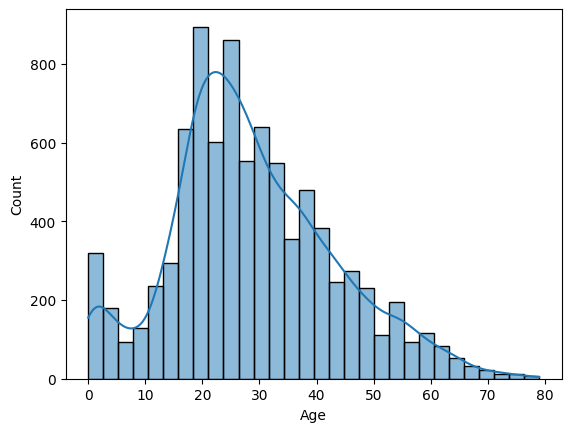

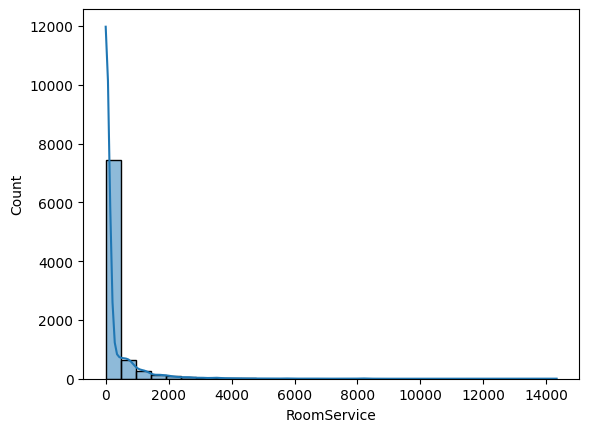

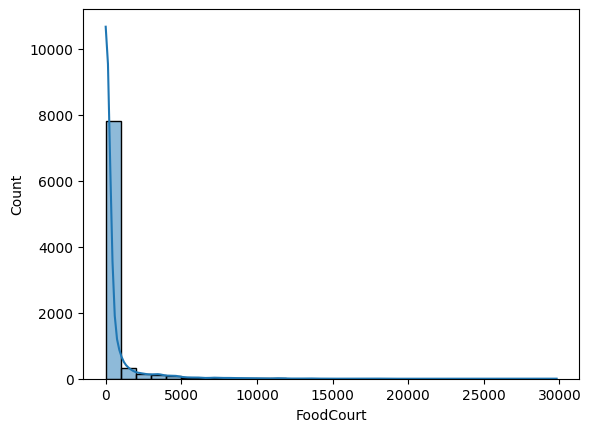

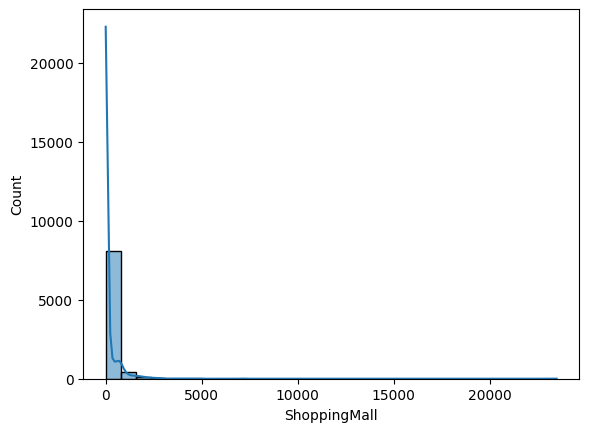

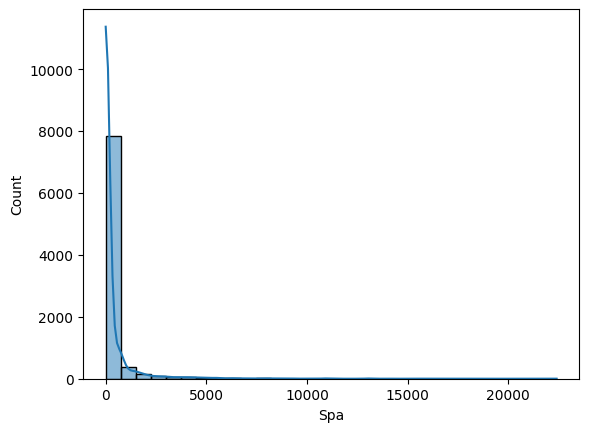

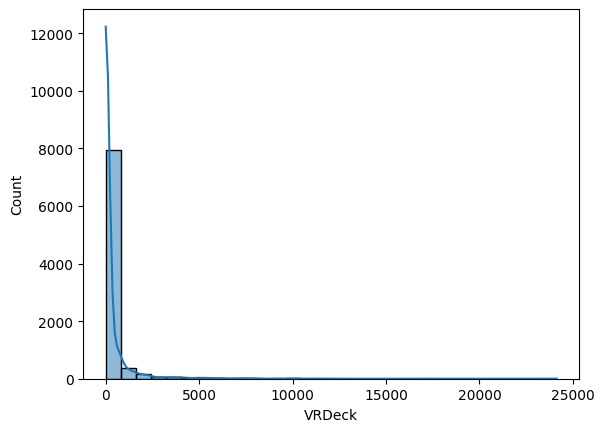

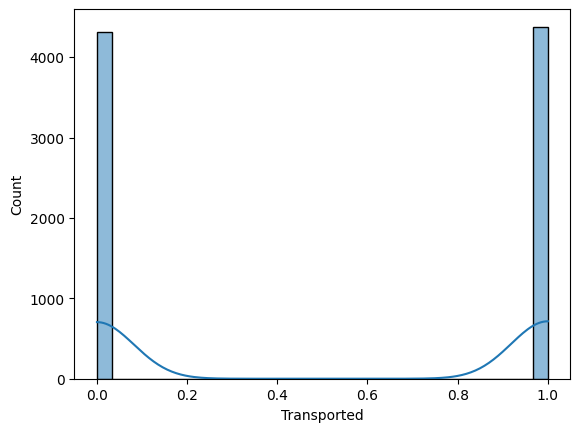

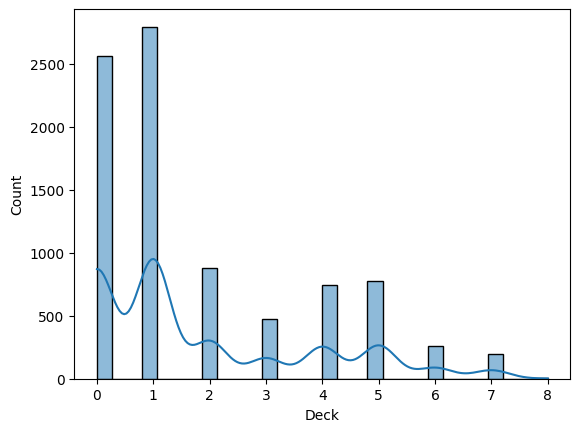

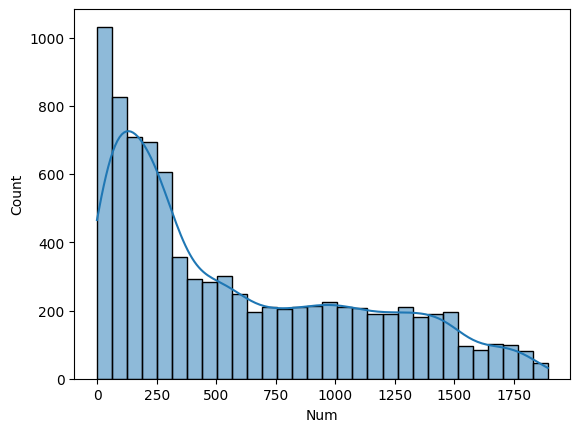

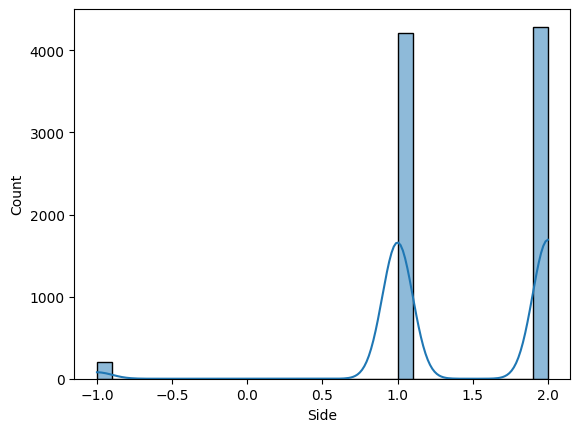

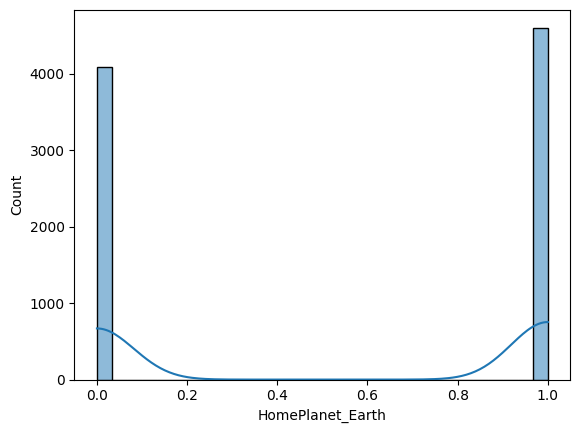

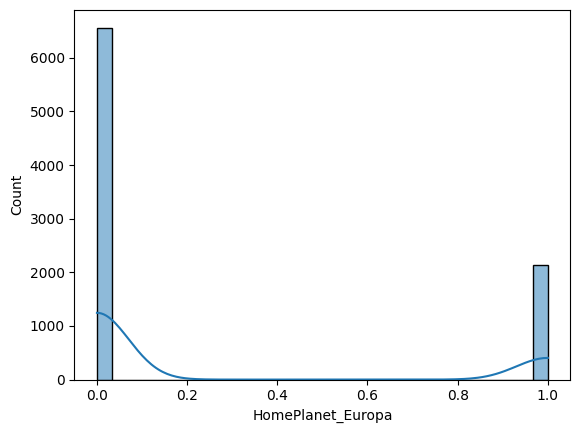

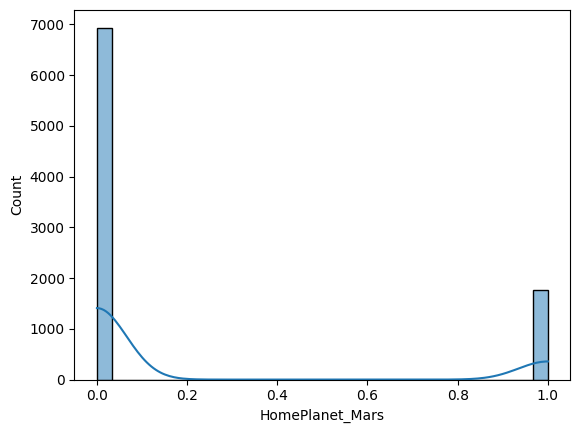

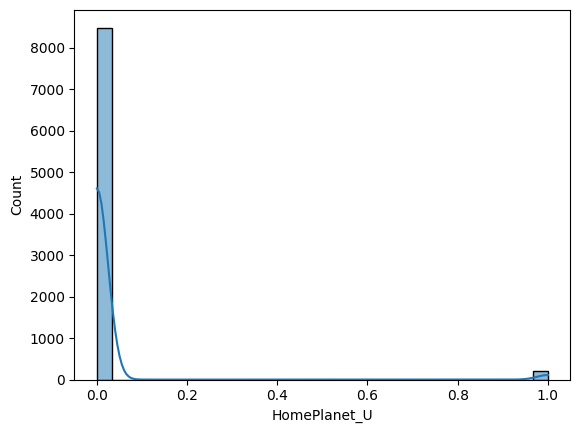

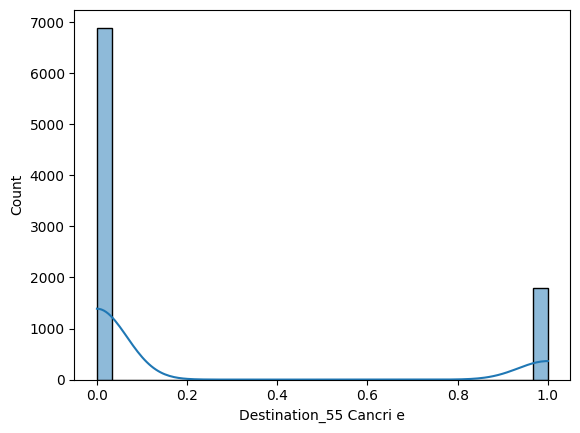

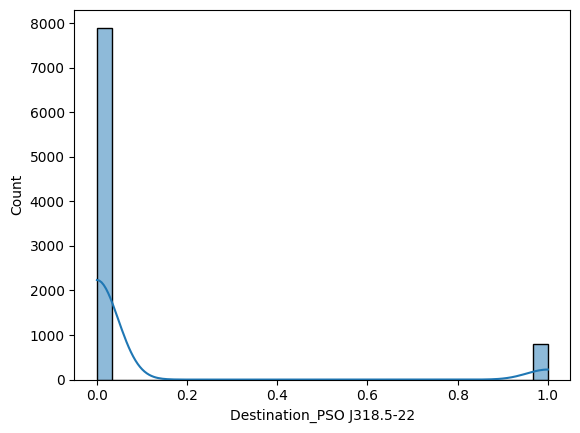

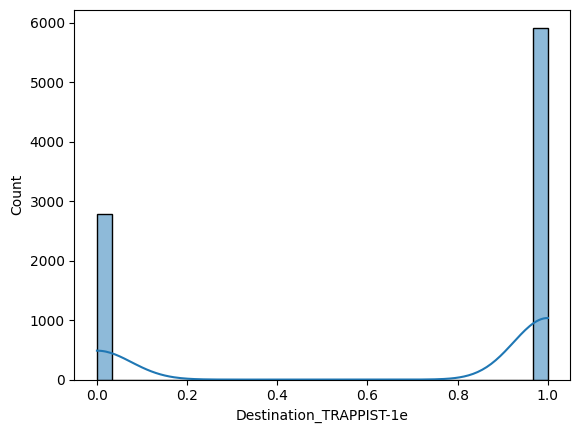

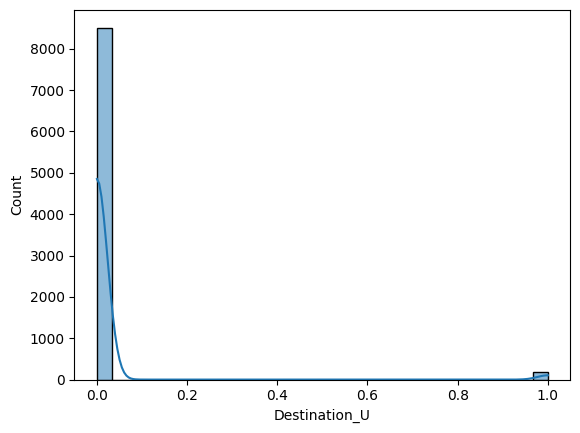

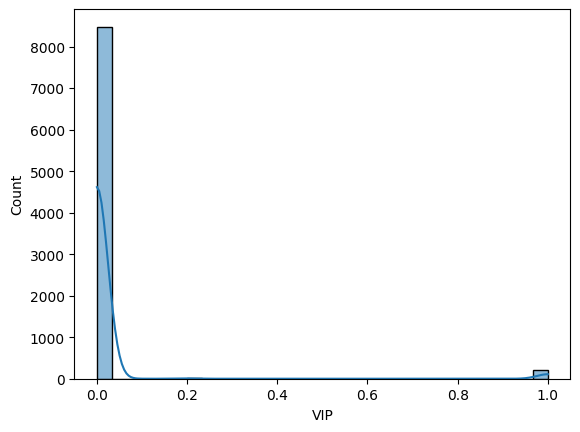

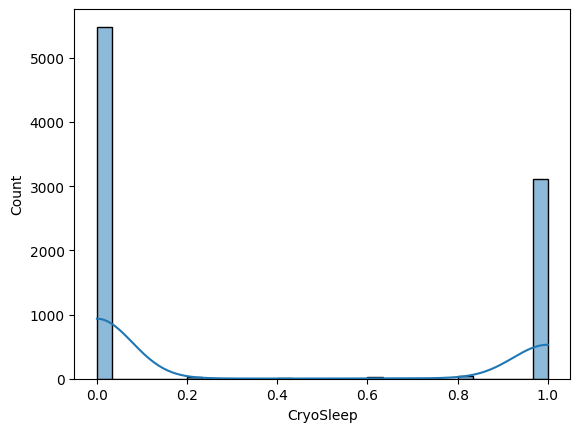

In [ ]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.show()
sns.histplot(df["RoomService"], bins=30, kde=True)
plt.show()
sns.histplot(df["FoodCourt"], bins=30, kde=True)
plt.show()
sns.histplot(df["ShoppingMall"], bins=30, kde=True)
plt.show()
sns.histplot(df["Spa"], bins=30, kde=True)
plt.show()
sns.histplot(df["VRDeck"], bins=30, kde=True)
plt.show()
sns.histplot(df["Transported"], bins=30, kde=True)
plt.show()
sns.histplot(df["Deck"], bins=30, kde=True)
plt.show()
sns.histplot(df["Num"], bins=30, kde=True)
plt.show()
sns.histplot(df["Side"], bins=30, kde=True)
plt.show()
sns.histplot(df["HomePlanet_Earth"], bins=30, kde=True)
plt.show()
sns.histplot(df["HomePlanet_Europa"], bins=30, kde=True)
plt.show()
sns.histplot(df["HomePlanet_Mars"], bins=30, kde=True)
plt.show()
sns.histplot(df["HomePlanet_U"], bins=30, kde=True)
plt.show()
sns.histplot(df["Destination_55 Cancri e"], bins=30, kde=True)
plt.show()
sns.histplot(df["Destination_PSO J318.5-22"], bins=30, kde=True)
plt.show()
sns.histplot(df["Destination_TRAPPIST-1e"], bins=30, kde=True)
plt.show()
sns.histplot(df["Destination_U"], bins=30, kde=True)
plt.show()
sns.histplot(df["VIP"], bins=30, kde=True)
plt.show()
sns.histplot(df["CryoSleep"], bins=30, kde=True)
plt.show()

plotting scatterplots

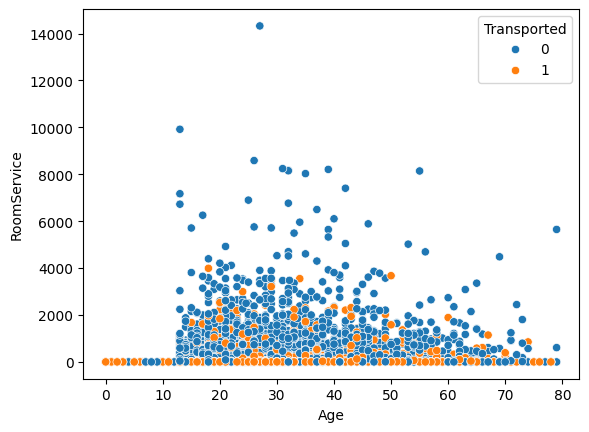

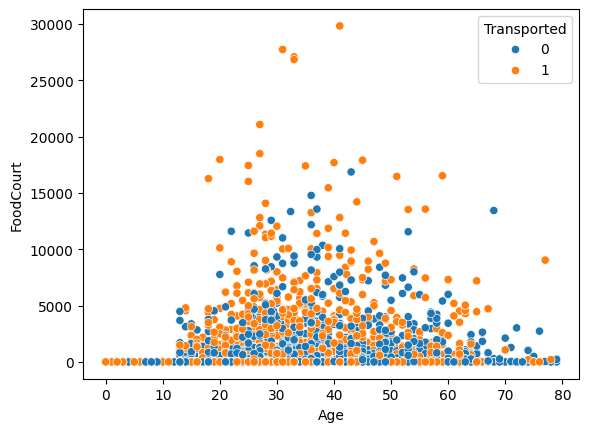

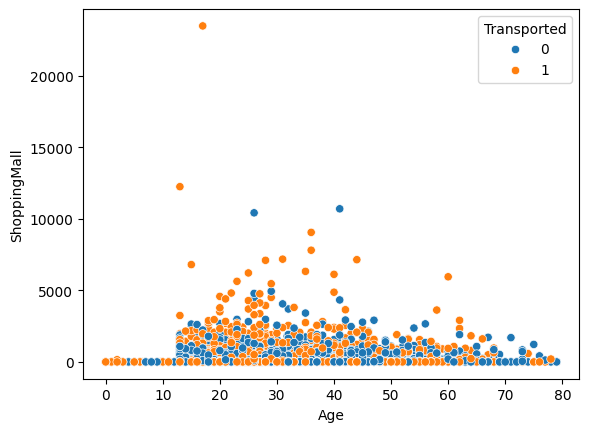

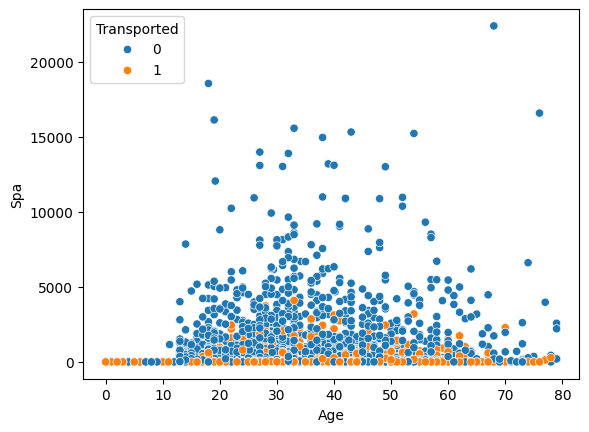

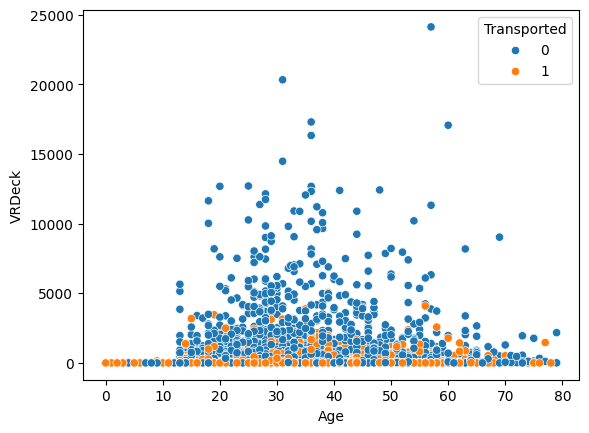

In [ ]:
sns.scatterplot(data=df,x="Age",y="RoomService",hue="Transported")
plt.show()
sns.scatterplot(data=df,x="Age",y="FoodCourt",hue="Transported")
plt.show()
sns.scatterplot(data=df,x="Age",y="ShoppingMall",hue="Transported")
plt.show()
sns.scatterplot(data=df,x="Age",y="Spa",hue="Transported")
plt.show()
sns.scatterplot(data=df,x="Age",y="VRDeck",hue="Transported")
plt.show()

plotting a pairplot of all columns

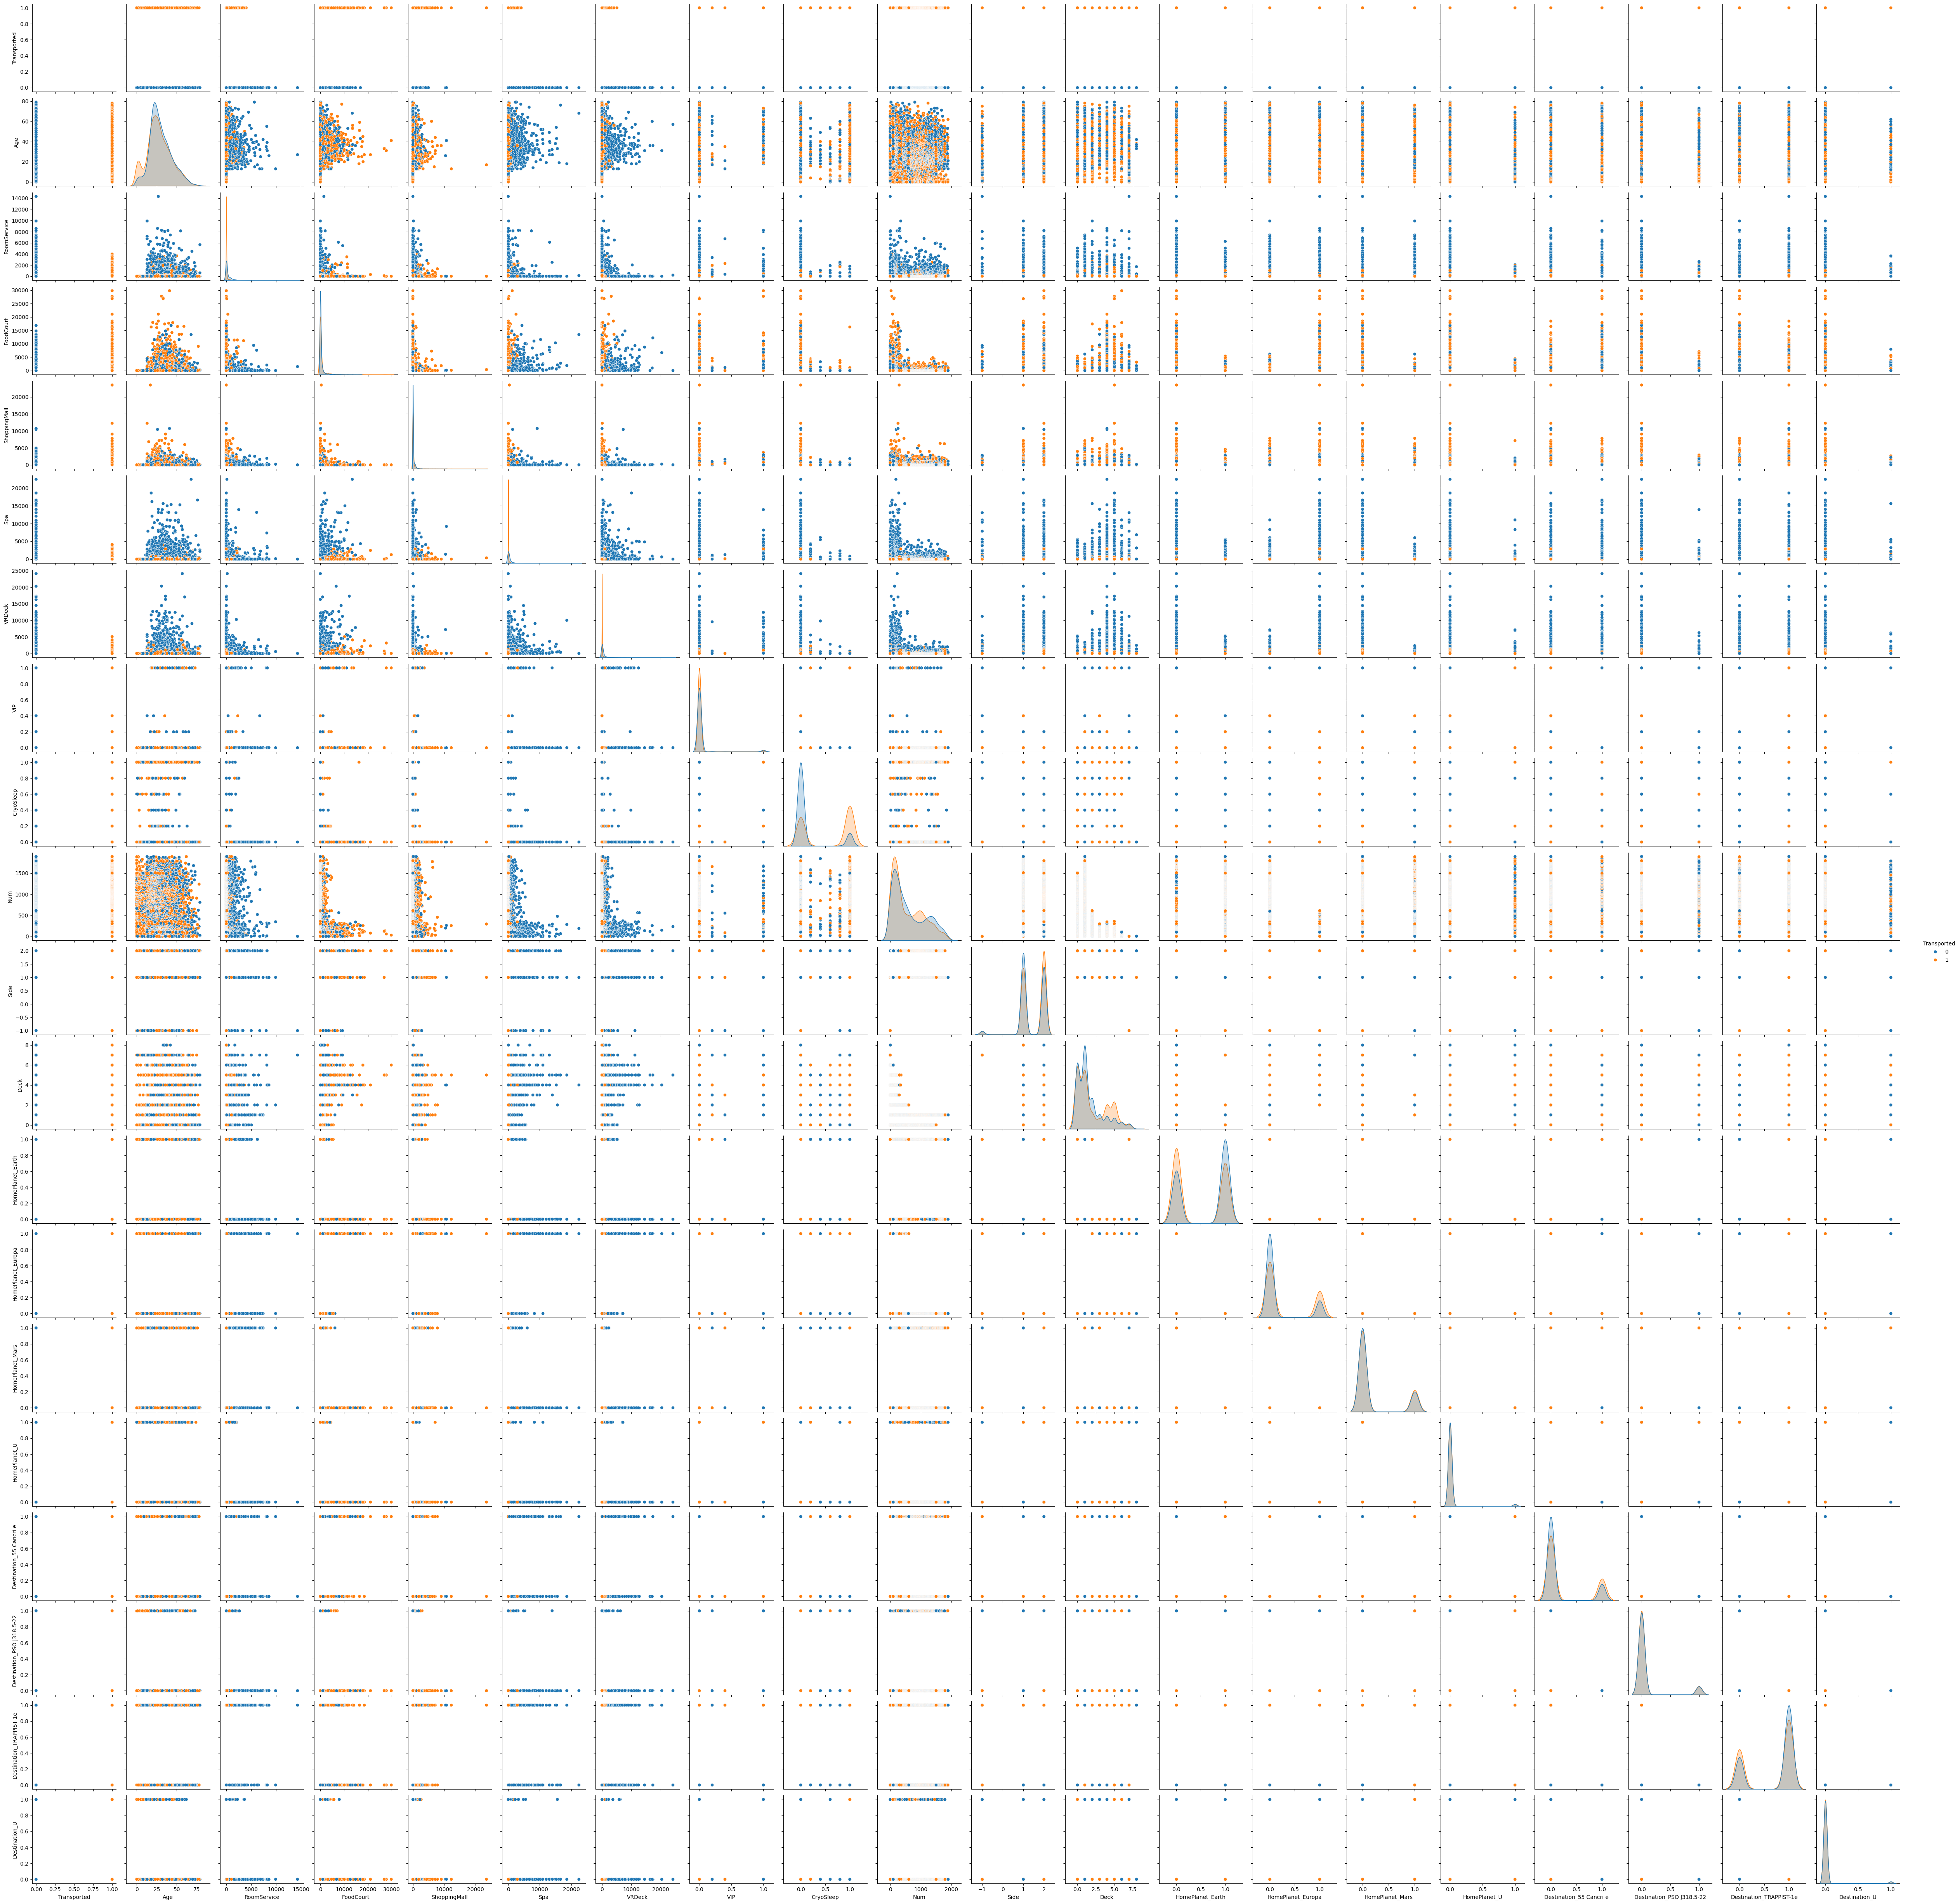

In [ ]:
sns.pairplot(df,vars=df.columns,hue='Transported')
plt.show()

Finding corelation using heatmap

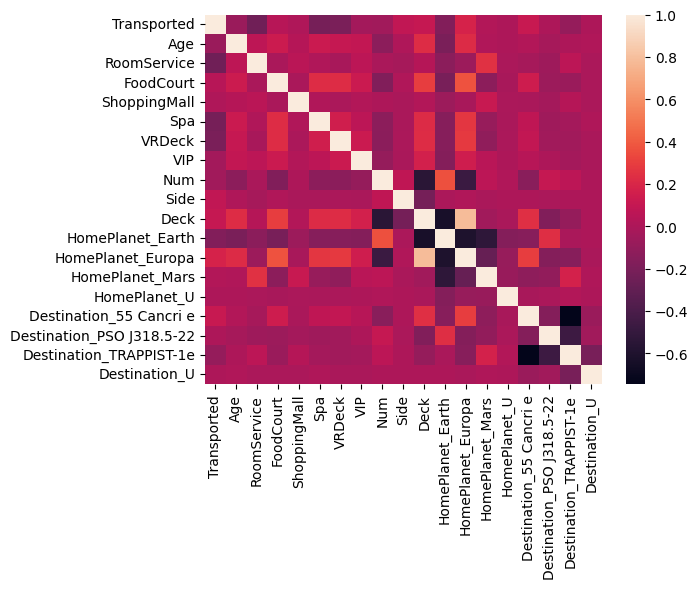

In [ ]:
df_corr=df.dropna().corr(numeric_only=True)

sns.heatmap(df_corr)
plt.show()

Fixing Outliers in the Data

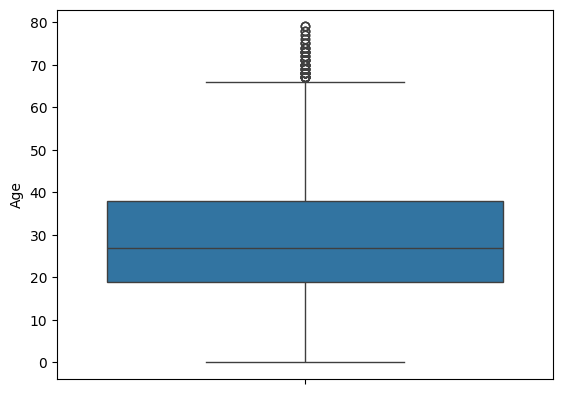

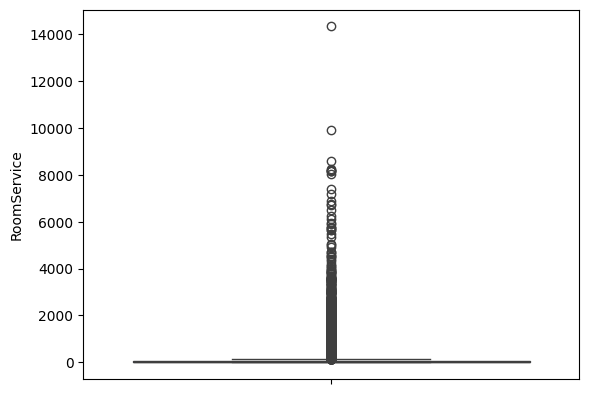

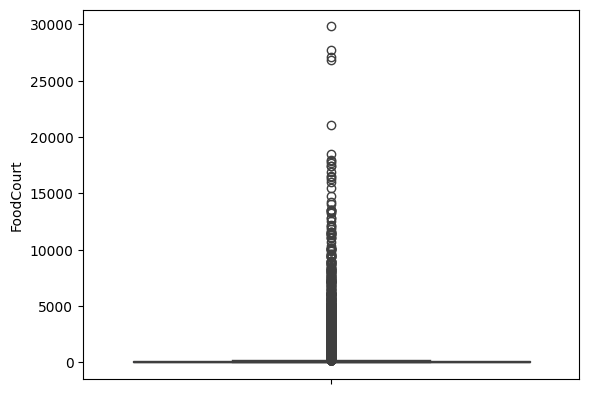

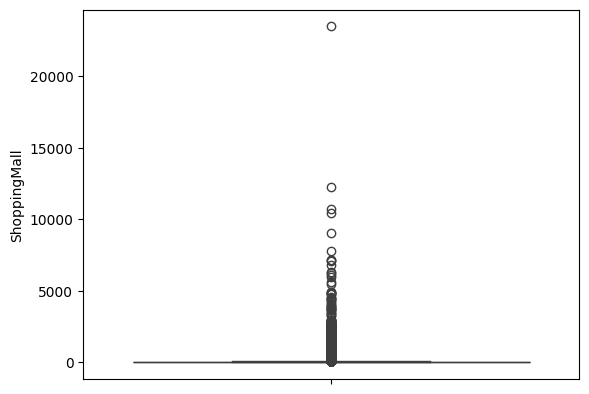

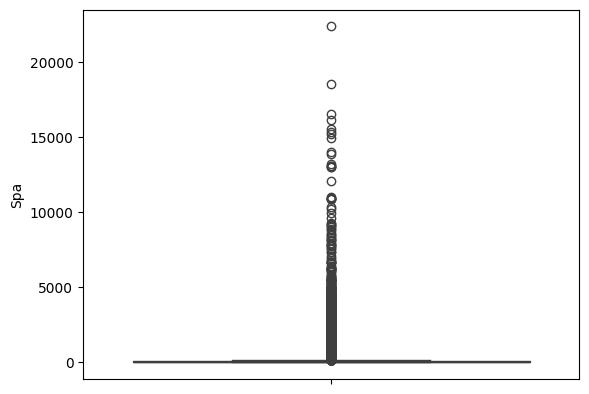

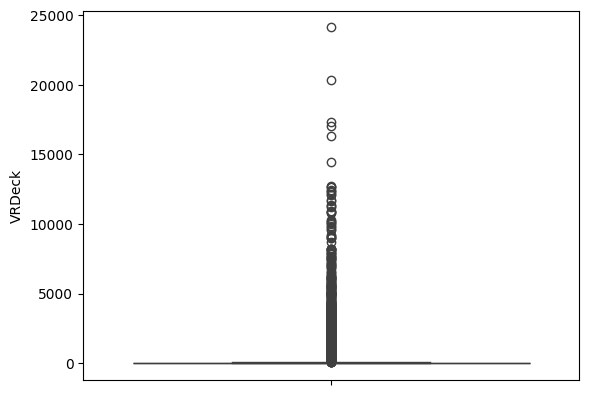

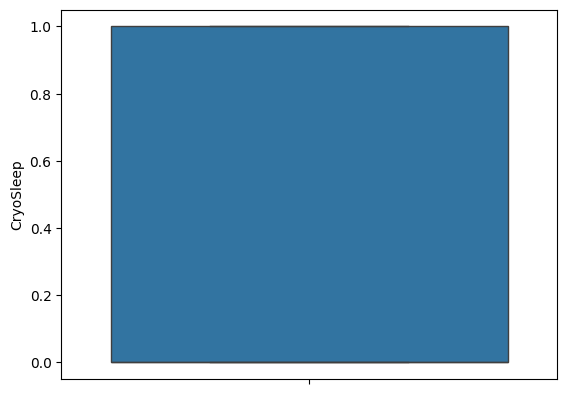

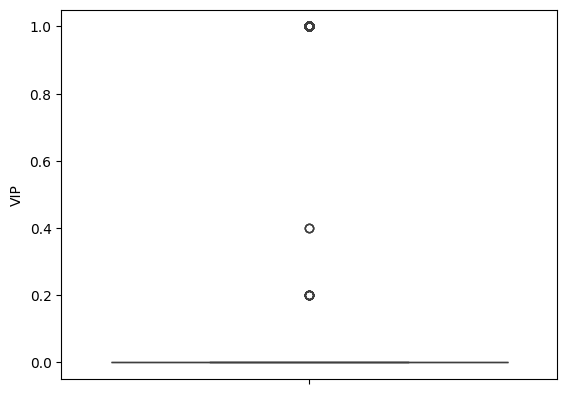

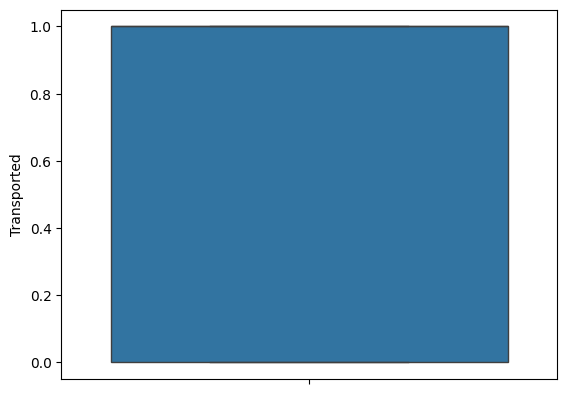

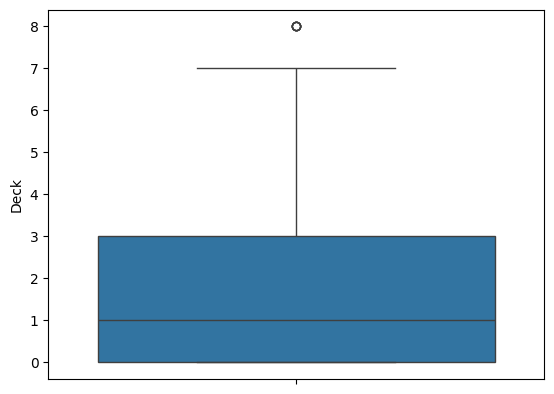

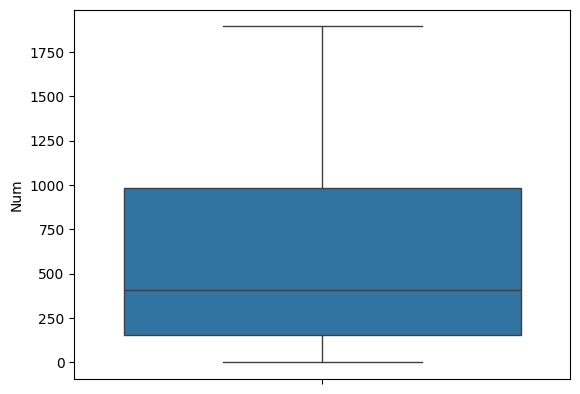

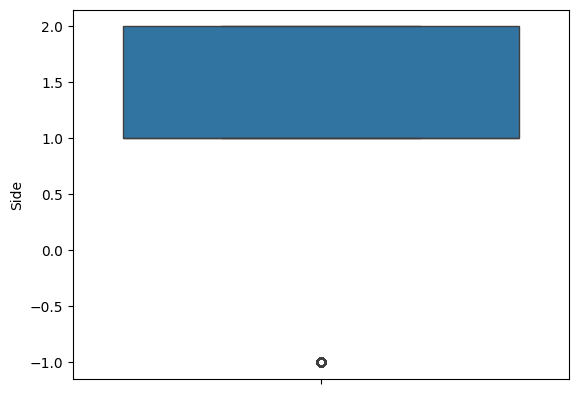

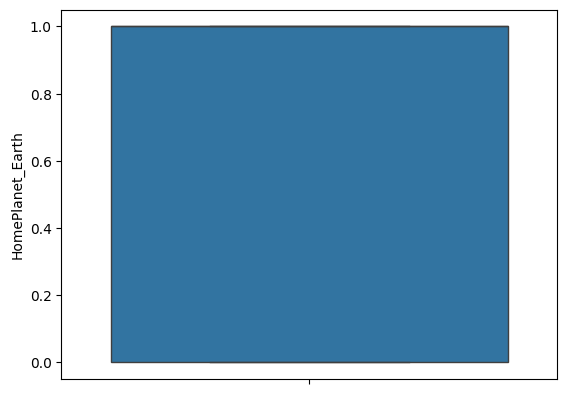

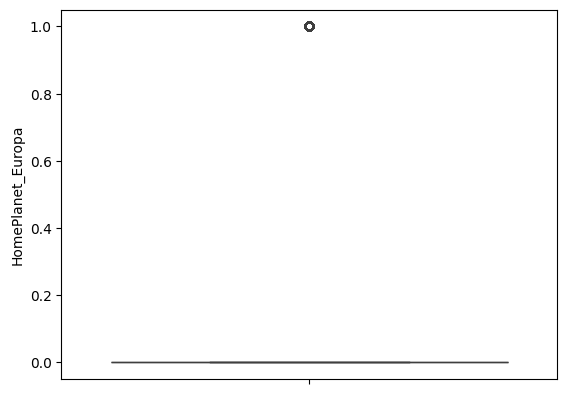

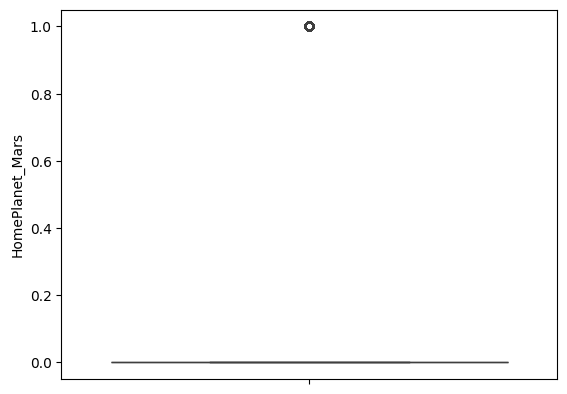

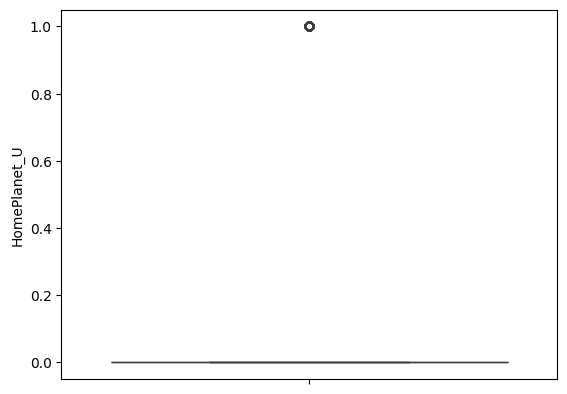

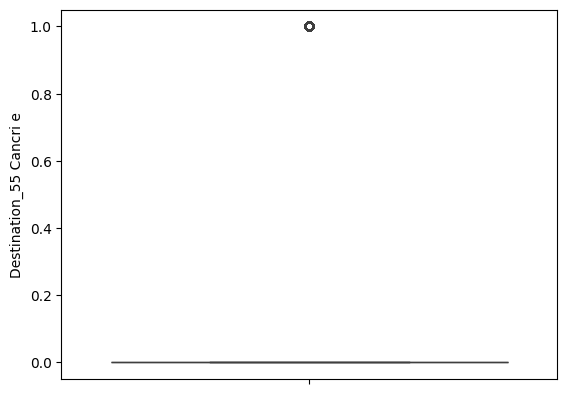

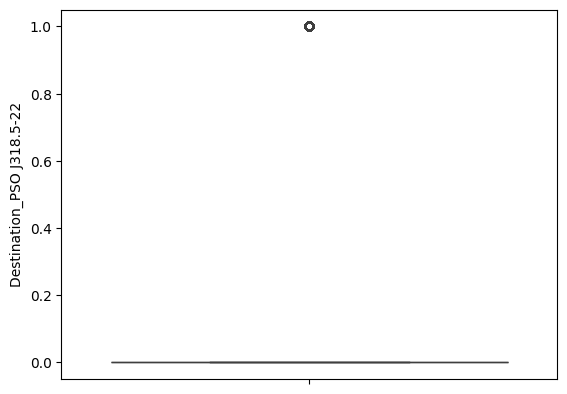

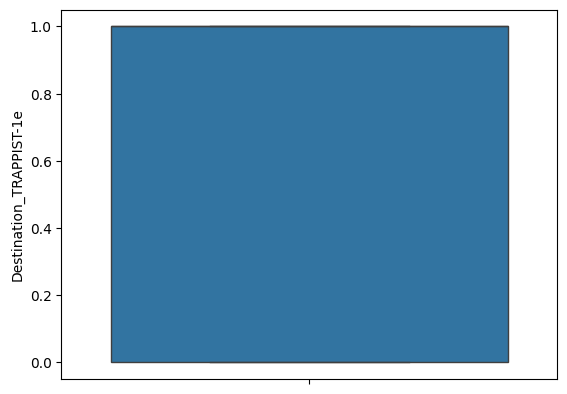

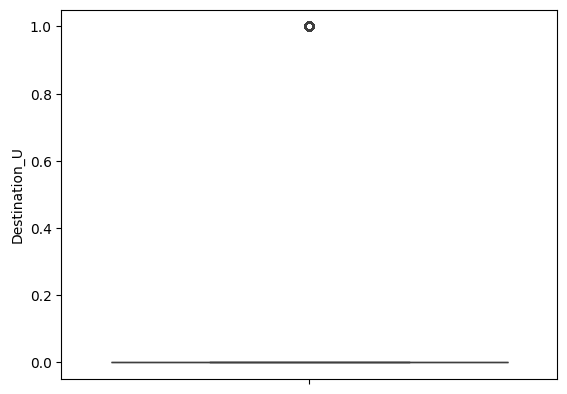

In [ ]:
sns.boxplot(df['Age'])
plt.show()
sns.boxplot(df['RoomService'])
plt.show()
sns.boxplot(df['FoodCourt'])
plt.show()
sns.boxplot(df['ShoppingMall'])
plt.show()
sns.boxplot(df['Spa'])
plt.show()
sns.boxplot(df['VRDeck'])
plt.show()
sns.boxplot(df['CryoSleep'])
plt.show()
sns.boxplot(df['VIP'])
plt.show()
sns.boxplot(df['Transported'])
plt.show()
sns.boxplot(df['Deck'])
plt.show()
sns.boxplot(df['Num'])
plt.show()
sns.boxplot(df['Side'])
plt.show()
sns.boxplot(df['HomePlanet_Earth'])
plt.show()
sns.boxplot(df['HomePlanet_Europa'])
plt.show()
sns.boxplot(df['HomePlanet_Mars'])
plt.show()
sns.boxplot(df['HomePlanet_U'])
plt.show()
sns.boxplot(df['Destination_55 Cancri e'])
plt.show()
sns.boxplot(df['Destination_PSO J318.5-22'])
plt.show()
sns.boxplot(df['Destination_TRAPPIST-1e'])
plt.show()
sns.boxplot(df['Destination_U'])
plt.show()


CryoSleep ,Transported,Deck,Num,Earth,Destination_Trappist-1e don't need fixing.

VIP feature has zero mathamatical varience so we can drop that feature directly.
we can't drop Cryosleep feature directly as an open box still contains valuable mathematical variance and predictive information. Deleting it can directly decrease classification accuracy.boxplot has no dots, it means 100% of your data points already fall within the mathematically safe range.

Applying Log Transformation on Roomservice,Shoppingmall,VRdeck,Spa,foodcourt

In [ ]:
df['RoomService']=np.log1p(df['RoomService'])
df['ShoppingMall']=np.log1p(df['ShoppingMall'])
df['VRDeck']=np.log1p(df['VRDeck'])
df['Spa']=np.log1p(df['Spa'])
df['FoodCourt']=np.log1p(df['FoodCourt'])

Applying percentile method and capping on Age to handle Outliers

65.0
0.0


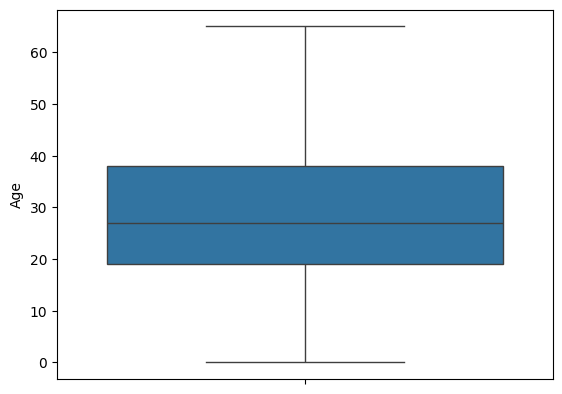

In [ ]:
upper_limit=df["Age"].quantile(0.99)
lower_limit=df["Age"].quantile(0.01)
print(upper_limit)
print(lower_limit)
df.loc[df["Age"]>upper_limit,"Age"]=upper_limit
df.loc[df["Age"]<lower_limit,"Age"]=lower_limit
sns.boxplot(df['Age'])
plt.show()

###Spliting the data


In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=["Transported"])
y=df["Transported"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True ,stratify=y,random_state=42)
x_test_v2,x_train_v2,y_test_v2,y_train_v2=x_test.copy(),x_train.copy(),y_test.copy(),y_train.copy()


###Baseline Model : Logistic regression with all features

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
preds=lr.predict(x_test)
from sklearn.metrics import f1_score
fi_score_all=round(f1_score(y_test,preds,average='weighted'),3)
print(fi_score_all)




0.772


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


###Performing Mutual Information Method of Feature Selection

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest
fi_score_list=[]
for k in range(1,21):
  selector=SelectKBest(mutual_info_classif,k=k)
  selector.fit(x_train_v2,y_train_v2)
  sel_x_train_v2=selector.transform(x_train_v2)
  sel_x_test_v2=selector.transform(x_test_v2)

  lr.fit(sel_x_train_v2,y_train_v2)
  kbest_preds=lr.predict(sel_x_test_v2)
  fi_score_kbest=round(f1_score(y_test_v2,kbest_preds,average='weighted'),3)
  fi_score_list.append(fi_score_kbest)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

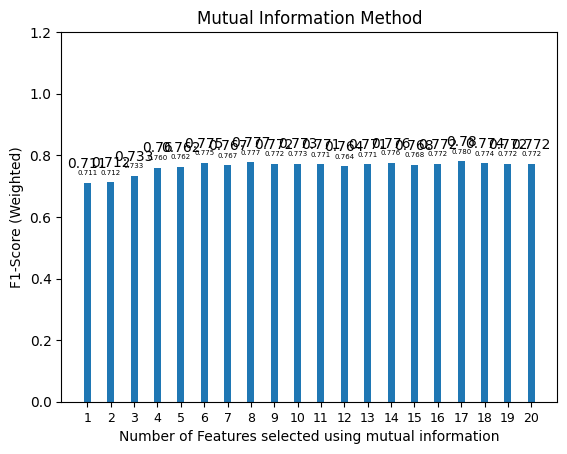

<Figure size 1500x1500 with 0 Axes>

In [ ]:
fig,ax=plt.subplots()
X=np.arange(1,21)
Y=fi_score_list
ax.bar(X,Y,width=0.3)
ax.set_xlabel('Number of Features selected using mutual information')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_title('Mutual Information Method')
ax.set_ylim(0,1.2)
ax.set_xticks(np.arange(1,21))
ax.set_xticklabels(np.arange(1,21),fontsize=9)
ax.bar_label(
     ax.containers[0],
    fmt='%.3f',
    padding=5,
    fontsize=5
)

for i,v in enumerate(Y):
  plt.text(x=i+1,y=v+0.05,s=str(v),ha='center')
plt.figure(figsize=(15,15))

plt.show()

 Feature Selection is Successful !!

 we are getting highest F1-Score of 0.780 with 12 features

In [ ]:
selector=SelectKBest(mutual_info_classif,k=12)
selector.fit(x_train_v2,y_train_v2)

selected_feature_mask=selector.get_support()
selected_features=x_train_v2.columns[selected_feature_mask]
print(selected_features)
df.head()

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CryoSleep', 'Num', 'Deck', 'HomePlanet_Earth', 'HomePlanet_Europa',
       'Destination_TRAPPIST-1e'],
      dtype='object')


,Transported,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,VIP,CryoSleep,Num,Side,Deck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_U,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Destination_U
0,0,39.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,5.0,0,1,0,0,0,0,1,0
1,1,24.0,4.700480,2.302585,3.258097,6.309918,3.806662,0.0,0.0,0.0,2.0,1.0,1,0,0,0,0,0,1,0
2,0,58.0,3.784190,8.182280,0.000000,8.812248,3.912023,1.0,0.0,0.0,2.0,6.0,0,1,0,0,0,0,1,0
3,0,33.0,0.000000,7.157735,5.918894,8.110728,5.267858,0.0,0.0,0.0,2.0,6.0,0,1,0,0,0,0,1,0
4,1,16.0,5.717028,4.262680,5.023881,6.338594,1.098612,0.0,0.0,1.0,2.0,1.0,1,0,0,0,0,0,1,0


###Performing Scaling  

In [ ]:
df=df.drop(columns=['VIP', 'HomePlanet_Mars', 'HomePlanet_U', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e',
      'Destination_U'],axis=1,errors='ignore')
x=df.drop(columns=["Transported"])
y=df["Transported"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True ,stratify=y,random_state=42)
X1=x.iloc[:,0:12]

from sklearn.preprocessing import StandardScaler
scaleStandard =StandardScaler()
X1=scaleStandard.fit_transform(X1)
X1=pd.DataFrame(X1,columns=['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CryoSleep', 'Num', 'Deck', 'HomePlanet_Earth', 'HomePlanet_Europa',
       'Destination_U'])
df.update(X1)
df.describe().round(3)

/tmp/ipykernel_861/1049392226.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.6444999  -0.42485741  2.16183922 ... -0.94219673  0.09248192
  0.09248192]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.update(X1)
/tmp/ipykernel_861/1049392226.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.06061696  0.94284745 -1.06061696 ...  0.94284745 -1.06061696
 -1.06061696]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.update(X1)


,Transported,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Num,Side,Deck,HomePlanet_Earth,HomePlanet_Europa
count,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000
mean,0.504,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,1.447,0.000,0.000,0.000
std,0.500,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.620,1.000,1.000,1.000
min,0.000,-2.020,-0.656,-0.663,-0.640,-0.681,-0.655,-1.143,-1.000,-3.947,-0.942,-1.061
25%,0.000,-0.684,-0.656,-0.663,-0.640,-0.681,-0.655,-0.846,1.000,-0.722,-0.942,-1.061
50%,1.000,-0.122,-0.656,-0.663,-0.640,-0.681,-0.655,-0.350,1.000,-0.722,-0.425,0.943
75%,1.000,0.651,0.814,0.824,0.686,0.823,0.780,0.771,2.000,0.891,0.610,0.943
max,1.000,2.549,2.835,2.833,3.247,2.914,2.992,2.544,2.000,0.891,3.197,0.943


Loading and Handling Data in Test file

In [ ]:
test=pd.read_csv("/content/test.csv")

passenger_ids = test["PassengerId"]

test[['Deck','Num','Side']]=test['Cabin'].str.split('/',expand=True)
test=test.drop(columns=["Cabin"])
test=test.drop(columns=["Name"])
test=test.drop(columns=["PassengerId"])

test['Deck']=test['Deck'].fillna('U')
test['Num']=test['Num'].fillna(-1)
test['Side']=test['Side'].fillna('U')

test['Deck']=test['Deck'].map({'G':0,'F':1,'E':2,'D':3,'C':4,'B':5,'A':6,'U':7,'T':8})
test['Side']=test['Side'].map({'U':-1,'P':1,'S':2})

impute_lis=['Age','RoomService','FoodCourt','ShoppingMall','Spa','VRDeck','VIP','CryoSleep','Num','Side','Deck']
rest=list(set(test.columns)-set(impute_lis))
test_rest=test[rest]
imp=KNNImputer(n_neighbors=5)
test_imputed=imp.fit_transform(test[impute_lis])
test_imputed=pd.DataFrame(test_imputed,columns=impute_lis)
test=pd.concat([test_rest.reset_index(drop=True),test_imputed.reset_index(drop=True)],axis=1)

test['HomePlanet'] = test['HomePlanet'].fillna('U').astype(str)
test['Destination'] = test['Destination'].fillna('U').astype(str)
test = pd.get_dummies(test, columns=['HomePlanet', 'Destination'], dtype=int)


test.loc[(test["CryoSleep"]==True) & (test["RoomService"].isna()),
       "RoomService"]=0
test.loc[(test["CryoSleep"]==True) & (test["Spa"].isna()),
       "Spa"]=0
test.loc[(test["CryoSleep"]==True) & (test["FoodCourt"].isna()),
       "FoodCourt"]=0
test.loc[(test["CryoSleep"]==True) & (test["VRDeck"].isna()),
       "VRDeck"]=0
test.loc[(test["CryoSleep"]==True) & (test["ShoppingMall"].isna()),
       "ShoppingMall"]=0


get_true=((test["RoomService"]==0)&
          (test["Spa"]==0) &
          (test["FoodCourt"]==0) &
          (test["VRDeck"]==0) &
          (test["ShoppingMall"]==0) &
          (test["CryoSleep"].isna())
          )
test.loc[get_true,"CryoSleep"]=True


test["RoomService"]=test["RoomService"].astype(float)
test["Spa"]=test["Spa"].astype(float)
test["FoodCourt"]=test["FoodCourt"].astype(float)
test["ShoppingMall"]=test["ShoppingMall"].astype(float)
test["VRDeck"]=test["VRDeck"].astype(float)

test['RoomService']=np.log1p(test['RoomService'])
test['ShoppingMall']=np.log1p(test['ShoppingMall'])
test['VRDeck']=np.log1p(test['VRDeck'])
test['Spa']=np.log1p(test['Spa'])
test['FoodCourt']=np.log1p(test['FoodCourt'])

test=test.drop(columns=['VIP', 'HomePlanet_Mars', 'HomePlanet_U', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e',
      'Destination_U'],axis=1,errors='ignore')
X1=test.iloc[:,0:12]
X1=scaleStandard.transform(X1)
X1=pd.DataFrame(X1,columns=['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'CryoSleep', 'Num', 'Deck', 'HomePlanet_Earth', 'HomePlanet_Europa',
       'Destination_U'])
test.update(X1)
test.describe().round(3)







/tmp/ipykernel_861/2509981193.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  test.loc[get_true,"CryoSleep"]=True
/tmp/ipykernel_861/2509981193.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.94219673 -0.42485741  1.12716057 ...  0.60982124  0.60982124
 -0.94219673]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.update(X1)
/tmp/ipykernel_861/2509981193.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.94284745  0.94284745 -1.06061696 ... -1.06061696 -1.06061696
  0.94284745]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test.update(X1)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Num,Side,Deck,HomePlanet_Earth,HomePlanet_Europa
count,4277.000,4277.000,4277.000,4277.000,4277.000,4277.000,4277.000,4277.000,4277.000,4277.000,4277.000
mean,-0.008,0.004,0.005,0.011,-0.010,-0.025,0.018,1.443,-0.008,-0.019,-0.001
std,0.990,1.001,1.000,1.008,0.993,0.990,1.007,0.622,1.003,0.980,1.000
min,-2.020,-0.656,-0.663,-0.640,-0.681,-0.655,-1.143,-1.000,-3.947,-0.942,-1.061
25%,-0.684,-0.656,-0.663,-0.640,-0.681,-0.655,-0.826,1.000,-0.722,-0.942,-1.061
50%,-0.192,-0.656,-0.663,-0.640,-0.681,-0.655,-0.332,1.000,-0.722,-0.425,0.943
75%,0.581,0.831,0.853,0.765,0.751,0.674,0.828,2.000,0.891,0.610,0.943
max,3.533,2.757,2.777,2.845,2.871,2.963,2.536,2.000,0.891,3.197,0.943


###Performing Final Data Splitting for All Models

In [ ]:
x_train=df.drop(columns=["Transported"])
y_train=df["Transported"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True ,stratify=y,random_state=42)

#Importing models

1.Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report
lr=LogisticRegression()


2.KNN

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
knn = KNeighborsClassifier()

3.Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

4.SVM

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

#Performing Hyperparameter Tuning

###Logistic Regression

In [ ]:
from sklearn.model_selection import GridSearchCV
parameter={'penalty': ['l1','l2'],'C':[1,2,3,5,8,10,20,30,50,80,100]}
lr_regressor=GridSearchCV(lr,param_grid=parameter,scoring='accuracy',cv=5)

###KNN

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],  # Number of neighbors
    'weights': ['uniform', 'distance'],       # Weight function used in prediction
    'metric': ['euclidean', 'manhattan']       # Distance metric
}

# Set up Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

###Naive Bayes

In [ ]:
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=100)
}
grid_search = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(x_train, y_train)
best_gnb=grid_search.best_estimator_

###SVM

In [ ]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'svm__kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

#Final Evaluation Of Models

###Logistic Regression

lr_regressor.fit(x_train,y_train)
preds=lr_regressor.predict(x_test)
y_pred=lr_regressor.predict(x_test)
accuracy_score(y_test,y_pred)
print(classification_report(y_test,y_pred))



In [ ]:
lr_regressor.fit(x_train,y_train)
preds=lr_regressor.predict(x_test)
y_pred=lr_regressor.predict(x_test)
score=accuracy_score(y_test,y_pred)
print(score)
print(classification_report(y_test,y_pred))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.7791834387579069
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       863
           1       0.76      0.82      0.79       876

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739



###KNN

In [ ]:
grid_search.fit(x_train_scaled, y_train)
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}\n")
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)


print("=== Final Test Set Evaluation ===")
print(f"Test Accuracy: {accuracy:.4f}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Best Parameters Found: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.8001

=== Final Test Set Evaluation ===
Test Accuracy: 0.7976

Confusion Matrix:
[[663 200]
 [152 724]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       863
           1       0.78      0.83      0.80       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



###Naive Bayes

In [50]:

y_pred = best_gnb.predict(x_test)
accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77       863
           1       0.78      0.74      0.76       876

    accuracy                           0.77      1739
   macro avg       0.77      0.77      0.77      1739
weighted avg       0.77      0.77      0.77      1739



###SVM

In [51]:
grid_search.fit(x_train, y_train)
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

KeyboardInterrupt: 

### Final Predictions Using KNN Model

In [ ]:
final_predictions = best_knn.predict(test)
final_predictions_bool = final_predictions.astype(bool)
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Transported": final_predictions_bool
})
submission.to_csv("submission.csv", index=False)
print("Successfully generated submission.csv!")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Successfully generated submission.csv!
